# Counts

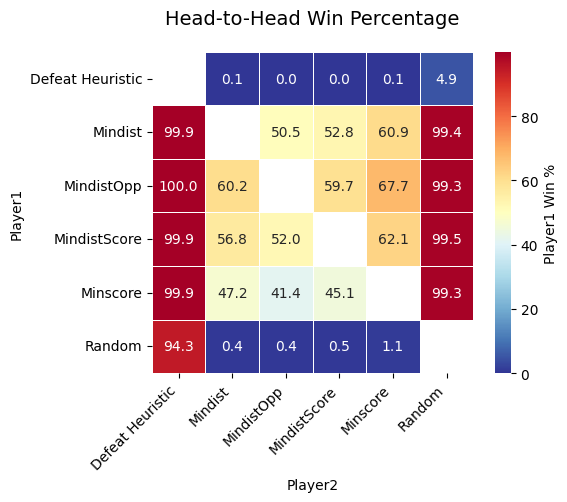

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data and get unique strategies
data = pd.read_csv('EloData.csv')
strategies = np.union1d(data['Player1'], data['Player2'])

# Vectorized computation
p1_wins = (data['Winner'] == 0).astype(int)
win_counts = data.groupby(['Player1', 'Player2']).agg({'Winner': lambda x: (x == 0).sum(), 'Player1': 'count'})
win_counts.columns = ['wins', 'total_games']

# Create matrices
win_matrix = pd.DataFrame(0, index=strategies, columns=strategies)
games_matrix = pd.DataFrame(0, index=strategies, columns=strategies)

for (p1, p2), row in win_counts.iterrows():
    win_matrix.loc[p1, p2] = row['wins']
    games_matrix.loc[p1, p2] = row['total_games']

# Compute win percentage
win_pct = (win_matrix / games_matrix.replace(0, np.nan)) * 100

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(win_pct, annot=True, fmt='.1f', cmap='RdYlBu_r', center=50,
            square=True, cbar_kws={'label': 'Player1 Win %'}, linewidths=0.5)
plt.title('Head-to-Head Win Percentage', fontsize=14, pad=20)
plt.xlabel('Player2')
plt.ylabel('Player1')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Rating Systems

In [2]:
import numpy as np

class RatingSystem:
    """Base class for rating systems"""
    def __init__(self, name, init_rating=1000):
        self.name = name
        self.init_rating = init_rating
        self.ratings = {}
        self.games = {}
        
    def initialize_player(self, player):
        if player not in self.ratings:
            self.ratings[player] = self.init_rating
            self.games[player] = 0
            
    def update(self, player1, player2, score1, score2, winner, **kwargs):
        """Override this method in subclasses"""
        raise NotImplementedError

class CustomEloSystem(RatingSystem):
    """Your custom Elo system with initial score consideration"""
    def __init__(self, K=-0.625, beta = -0.01269, alpha = 0.0032):
        super().__init__("Custom Elo", init_rating=1000)
        self.K = K
        self.beta = beta
        self.alpha = alpha
        
    def update(self, player1, player2, score1, score2, winner, init_score1=0, init_score2=0):
        self.initialize_player(player1)
        self.initialize_player(player2)
        
        # Store initial ratings
        init_rating1 = self.ratings[player1]
        init_rating2 = self.ratings[player2]
        
        # Calculate expected scores
        A = score1 + score2
        D = self.ratings[player1] - self.ratings[player2]
        I = init_score1 - init_score2
        
        B1 = A / (1 + 10**(self.alpha*D + self.beta*I))
        B2 = A - B1
        
        # Check if prediction matches actual winner
        predicted_winner = 1 if (score1 - B1) > 0 else 0
        flag = 1 if predicted_winner != winner else 0
        
        # Update ratings only if prediction was correct
        if flag == 0:
            change1 = round(self.K * (score1 - B1))
            change2 = round(self.K * (score2 - B2))
            self.ratings[player1] += change1
            self.ratings[player2] += change2
        else:
            change1 = 0
            change2 = 0
        
        self.games[player1] += 1
        self.games[player2] += 1
        
        return {
            'init_rating1': init_rating1,
            'init_rating2': init_rating2,
            'rating1': self.ratings[player1],
            'rating2': self.ratings[player2],
            'change1': change1,
            'score_diff': round(score1 - B1, 3)
        }

class StandardEloSystem(RatingSystem):
    """Standard Elo rating system"""
    def __init__(self, K=32):
        super().__init__("Standard Elo", init_rating=1000)
        self.K = K
        
    def update(self, player1, player2, score1, score2, winner, **kwargs):
        self.initialize_player(player1)
        self.initialize_player(player2)
        
        init_rating1 = self.ratings[player1]
        init_rating2 = self.ratings[player2]
        
        # Expected scores
        E1 = 1 / (1 + 10**((self.ratings[player2] - self.ratings[player1]) / 400))
        E2 = 1 - E1
        
        # Actual scores (1 for win, 0 for loss)
        S1 = 1 if winner == 0 else 0
        S2 = 1 - S1
        
        # Update ratings
        change1 = round(self.K * (S1 - E1))
        change2 = round(self.K * (S2 - E2))
        
        self.ratings[player1] += change1
        self.ratings[player2] += change2
        
        self.games[player1] += 1
        self.games[player2] += 1
        
        return {
            'init_rating1': init_rating1,
            'init_rating2': init_rating2,
            'rating1': self.ratings[player1],
            'rating2': self.ratings[player2],
            'change1': change1,
            'score_diff': S1 - E1
        }

class CustomEloSystem2(RatingSystem):
    """Your custom Elo system with initial score consideration"""
    def __init__(self, K=40):
        super().__init__("Custom Elo", init_rating=1000)
        self.K = K
        
    def update(self, player1, player2, score1, score2, winner, init_score1, init_score2):
        self.initialize_player(player1)
        self.initialize_player(player2)
        
        init_rating1 = self.ratings[player1]
        init_rating2 = self.ratings[player2]
        
        # Expected scores
        E1 = 1 / (1 + 10**((self.ratings[player2] - self.ratings[player1]) / 300 + (init_score1 - init_score2)/40))
        E2 = 1 - E1
        
        # Actual scores (1 for win, 0 for loss)
        S1 = 1 if winner == 0 else 0
        S2 = 1 - S1
        
        # Update ratings
        change1 = round(self.K * (S1 - E1))
        change2 = round(self.K * (S2 - E2))
        
        self.ratings[player1] += change1
        self.ratings[player2] += change2
        
        self.games[player1] += 1
        self.games[player2] += 1
        
        return {
            'init_rating1': init_rating1,
            'init_rating2': init_rating2,
            'rating1': self.ratings[player1],
            'rating2': self.ratings[player2],
            'change1': change1,
            'score_diff': S1 - E1
        }

def compare_rating_systems(filename, systems, max_games=45000, seed=1234):
    """Compare multiple rating systems on the same data"""
    
    # Read and shuffle data
    data = pd.read_csv(filename)
    np.random.seed(seed)
    data = data.sample(frac=1).reset_index(drop=True)
    
    # Get unique players
    players = pd.unique(data[['Player1', 'Player2']].values.ravel('K'))
    
    # Initialize dynamic ratings storage
    dynamic_ratings = {}
    for name in systems.keys():
        dynamic_ratings[name] = pd.DataFrame(index=np.arange(max_games), columns=players)
    
    # Process each game
    results = {name: [] for name in systems.keys()}
    
    for i in range(len(data)):
        player1 = data.loc[i, 'Player1']
        player2 = data.loc[i, 'Player2']
        score1 = data.loc[i, 'Final.Score1']
        score2 = data.loc[i, 'Final.Score2']
        winner = data.loc[i, 'Winner']
        init_score1 = data.loc[i, 'Init.Score1']
        init_score2 = data.loc[i, 'Init.Score2']
        
        # Update each system
        for name, system in systems.items():
            result = system.update(
                player1, player2, score1, score2, winner,
                init_score1=init_score1, init_score2=init_score2
            )
            results[name].append(result)
            
            # Store dynamic ratings
            if system.games[player1] < max_games:
                dynamic_ratings[name].loc[system.games[player1], player1] = system.ratings[player1]
            if system.games[player2] < max_games:
                dynamic_ratings[name].loc[system.games[player2], player2] = system.ratings[player2]
    
    # Convert results to dataframes
    result_dfs = {}
    for name in systems.keys():
        result_df = data.copy()
        result_df[f'{name}_init_rating1'] = [r['init_rating1'] for r in results[name]]
        result_df[f'{name}_init_rating2'] = [r['init_rating2'] for r in results[name]]
        result_df[f'{name}_rating1'] = [r['rating1'] for r in results[name]]
        result_df[f'{name}_rating2'] = [r['rating2'] for r in results[name]]
        result_df[f'{name}_change1'] = [r['change1'] for r in results[name]]
        result_df[f'{name}_score_diff'] = [r['score_diff'] for r in results[name]]
        result_dfs[name] = result_df
    
    # Convert dynamic ratings to float
    for name in dynamic_ratings.keys():
        dynamic_ratings[name].index.name = 'Games'
        dynamic_ratings[name] = dynamic_ratings[name].astype('float')
    
    return dynamic_ratings, systems, result_dfs


In [17]:
# Initialize rating systems
systems = {
    'Custom': CustomEloSystem(K=-0.625),
    'Elo': StandardEloSystem(K=50),
    'Custom2': CustomEloSystem2(K=50)
}
# Run comparison
dynamic_ratings, systems, result_dfs = compare_rating_systems('EloData.csv',systems,max_games=45000)

C:\Users\chakr\AppData\Local\Temp\ipykernel_11788\968012212.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap(palette, len(players_to_plot))


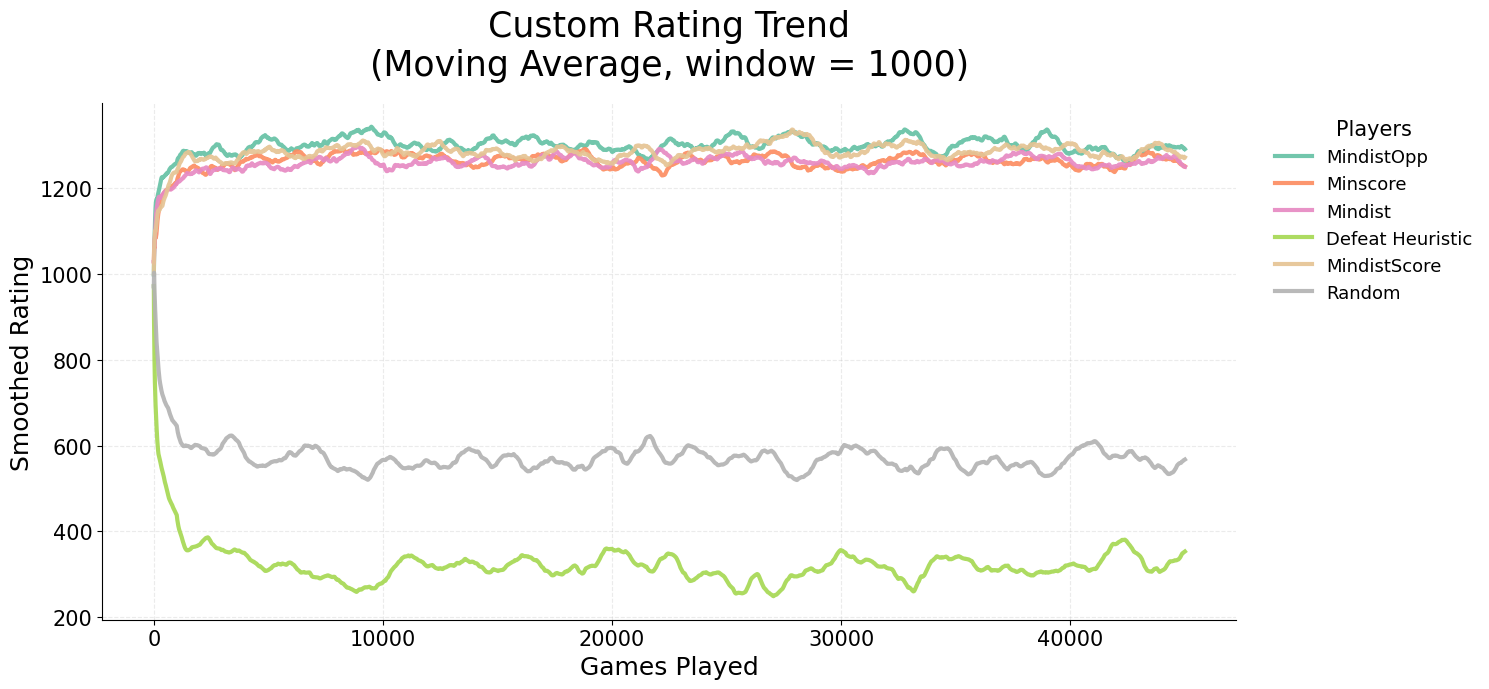

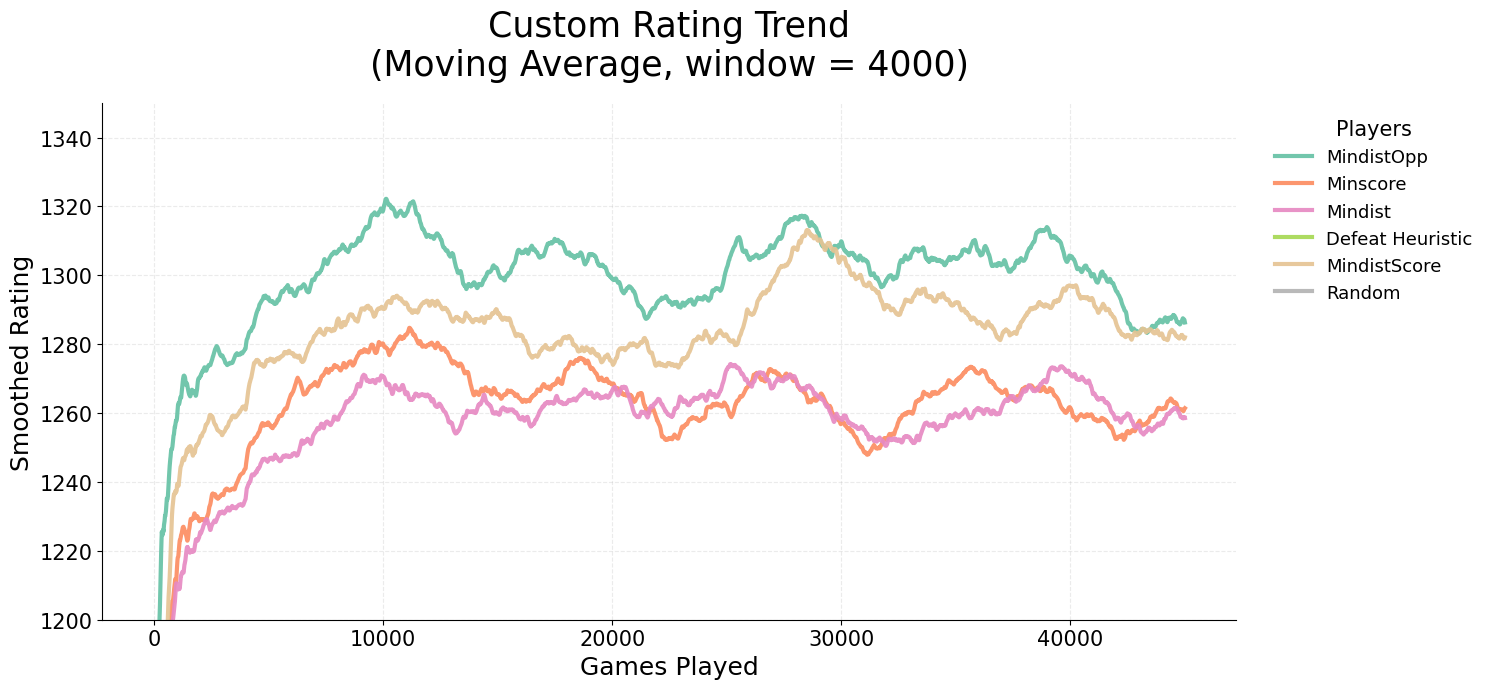

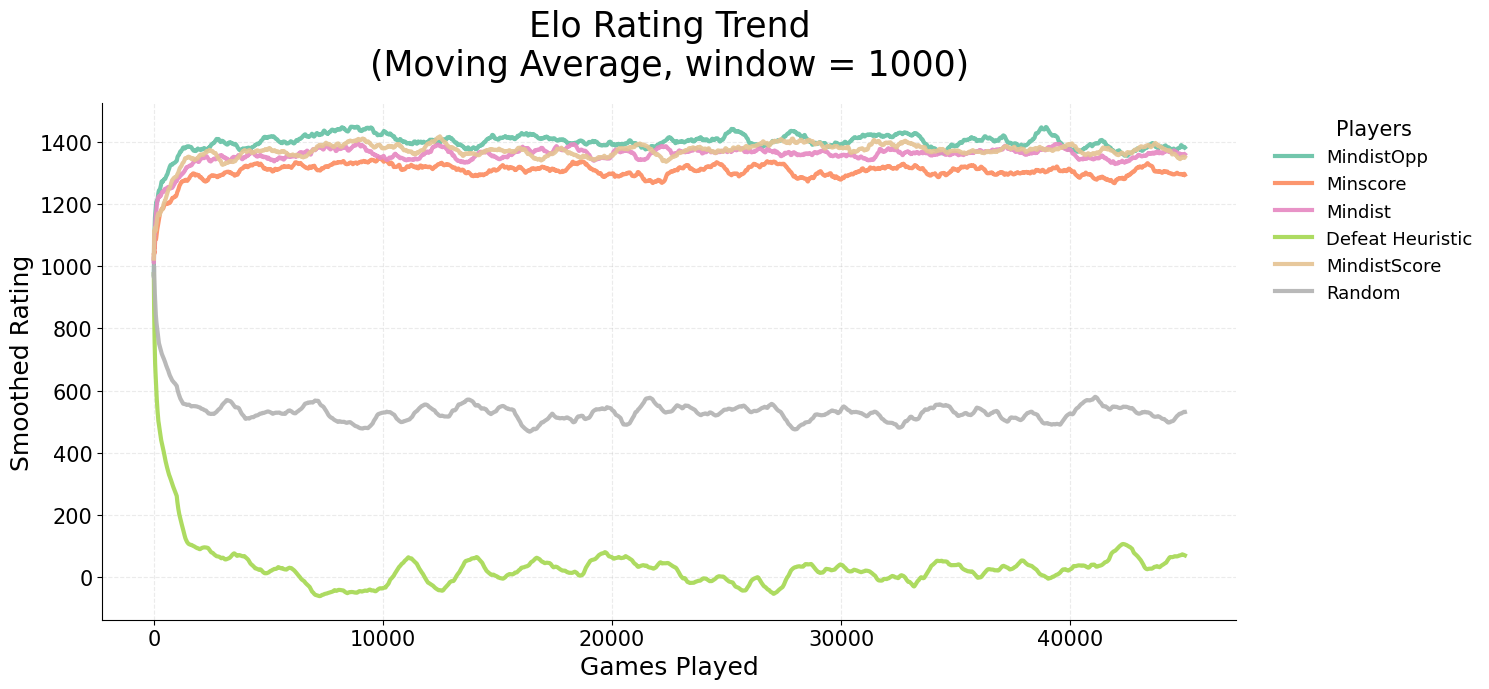

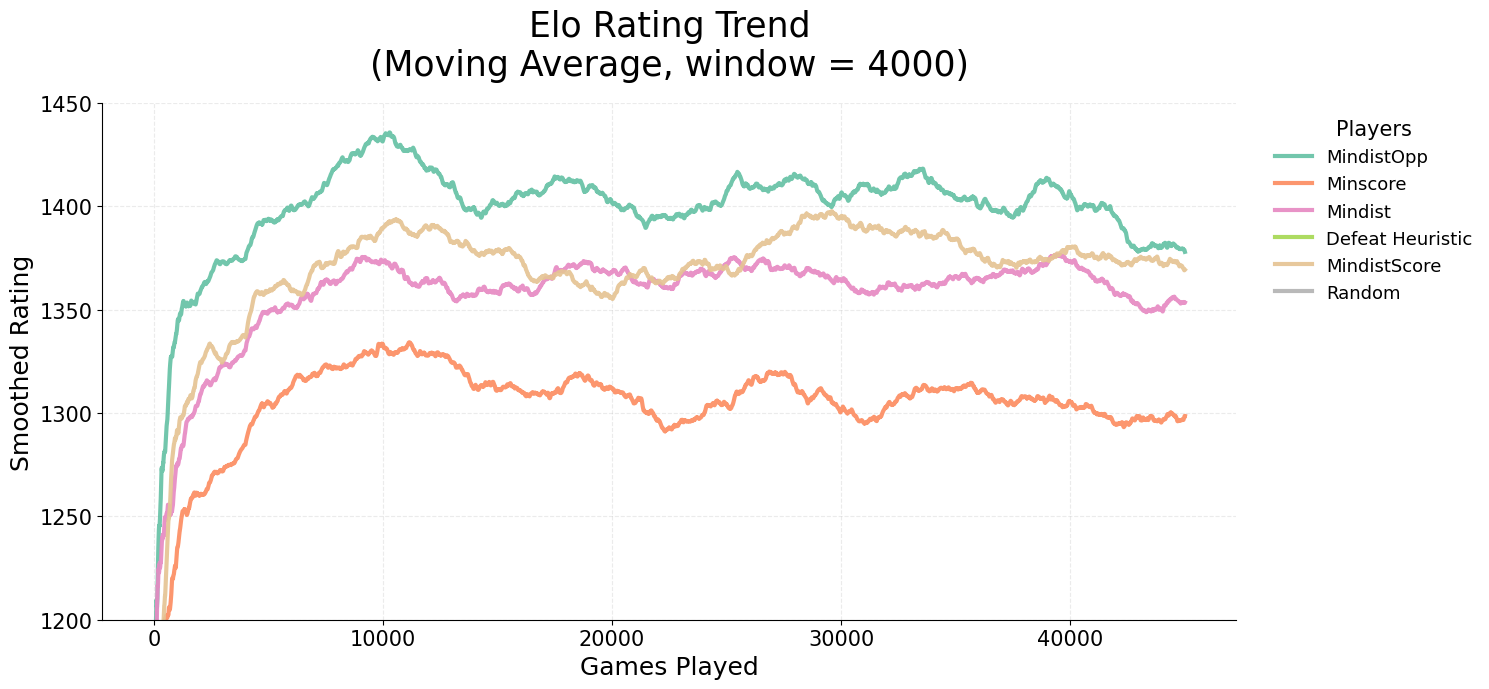

In [20]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_single_rating_mavg(dynamic_ratings, system_key, players_to_plot=None,
                                   window=4000,ylim = None, figsize=(15, 7), palette="Set2"):
    """
    Publication-quality moving average plot for rating evolution.
    """
    if system_key not in dynamic_ratings:
        raise ValueError(f"System '{system_key}' not found.")
    
    df = dynamic_ratings[system_key]

    if players_to_plot is None:
        players_to_plot = list(df.columns)
    
    # Color palette
    colors = plt.cm.get_cmap(palette, len(players_to_plot))
    mpl.rcParams["axes.prop_cycle"] = mpl.cycler(color=[colors(i) for i in range(len(players_to_plot))])

    plt.figure(figsize=figsize)
    
    # Plot smoothed curves
    for i, player in enumerate(players_to_plot):
        if player in df.columns:
            smooth = df[player].rolling(window, min_periods=1).mean()
            plt.plot(smooth, linewidth=3, alpha=0.92, label=player)
    
    # Styling
    plt.title(f"{system_key} Rating Trend\n(Moving Average, window = {window})",
              fontsize=25, pad=20)

    plt.xlabel("Games Played", fontsize=18)
    plt.ylabel("Smoothed Rating", fontsize=18)
    plt.ylim(ylim)

    plt.grid(alpha=0.25, linestyle="--")
    plt.tick_params(axis='both', labelsize=15)
    
    # Legend outside, clean formatting
    plt.legend(
        title="Players", title_fontsize=15, fontsize=13,
        bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False
    )

    # Remove top + right border 
    for spine in ["top", "right"]:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

# Plot evolution
fig = plot_single_rating_mavg(dynamic_ratings,'Custom',window = 1000)
plt.show()
fig = plot_single_rating_mavg(dynamic_ratings,'Custom',window = 4000, ylim = (1200,1350))
plt.show()
fig = plot_single_rating_mavg(dynamic_ratings,'Elo',window = 1000)
plt.show()
fig = plot_single_rating_mavg(dynamic_ratings,'Elo',window = 4000, ylim = (1200,1450))
plt.show()
# Access individual system results
custom_results = dynamic_ratings['Custom']
elo_results = dynamic_ratings['Elo']

In [19]:
for system in dynamic_ratings.keys():
    d = pd.concat([dynamic_ratings[system].mean(), dynamic_ratings[system].std(), 
                  (dynamic_ratings[system].std() / dynamic_ratings[system].mean()) * 100], axis=1)
    d.columns = ['Mean', 'SD', 'CV']
    d = d.sort_values('Mean', ascending=False)  # Sort by Mean descending
    print('\n' + system)
    print(d)


Custom
                         Mean         SD         CV
MindistOpp        1300.788106  43.985862   3.381478
MindistScore      1285.526367  43.387827   3.375102
Minscore          1263.768973  39.813471   3.150376
Mindist           1259.681415  41.447338   3.290303
Random             569.827996  42.807118   7.512288
Defeat Heuristic   320.049090  46.736830  14.603019

Elo
                         Mean         SD          CV
MindistOpp        1402.203538  65.424648    4.665845
MindistScore      1373.527034  64.398881    4.688578
Mindist           1361.234227  62.869574    4.618571
Minscore          1307.486655  63.010687    4.819222
Random             529.055001  49.731810    9.400121
Defeat Heuristic    26.100624  67.062600  256.938681

Custom2
                         Mean         SD            CV
MindistOpp        1412.262939  66.128284      4.682434
MindistScore      1382.730083  65.398333      4.729653
Mindist           1366.222916  63.642966      4.658315
Minscore          1307.

# Parameter Tuning

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
from itertools import product
import warnings
from joblib import Parallel, delayed
warnings.filterwarnings('ignore')

def evaluate_elo_params(params, train_data, test_data, K=-0.625, random_state=42):
    """Evaluate a single parameter combination"""
    alpha, beta = params
    
    try:
        # Unpack pre-extracted data
        (train_players1, train_players2, train_scores1, train_scores2, 
         train_winners, train_init1, train_init2) = train_data
        
        (test_players1, test_players2, test_scores1, test_scores2,
         test_winners, test_init1, test_init2) = test_data
        
        # Initialize Elo system with current parameters
        elo = CustomEloSystem(K=K, beta=beta, alpha=alpha)
        
        # Process training data
        train_features = []
        
        for j in range(len(train_players1)):
            result = elo.update(
                train_players1[j], train_players2[j], 
                train_scores1[j], train_scores2[j], 
                train_winners[j],
                train_init1[j], train_init2[j]
            )
            
            # Feature: rating difference (Player1 - Player2)
            rating_diff = result['init_rating1'] - result['init_rating2']
            train_features.append([rating_diff])
        
        # Process test data
        test_features = []
        
        for j in range(len(test_players1)):
            # Initialize players if not seen
            elo.initialize_player(test_players1[j])
            elo.initialize_player(test_players2[j])
            
            # Get current ratings before update
            rating_diff = elo.ratings[test_players1[j]] - elo.ratings[test_players2[j]]
            test_features.append([rating_diff])
            
            # Update ratings for next iteration
            elo.update(
                test_players1[j], test_players2[j],
                test_scores1[j], test_scores2[j], 
                test_winners[j],
                test_init1[j], test_init2[j]
            )
        
        # Train and evaluate model
        lr = LogisticRegression(random_state=random_state, max_iter=1000)
        lr.fit(train_features, train_winners)
        
        # Predict on test set
        test_pred = lr.predict(test_features)
        
        # Calculate metrics
        f1 = f1_score(test_winners, test_pred)
        accuracy = accuracy_score(test_winners, test_pred)
        
        print(f"α={alpha:7.4f}, β={beta:7.4f} → F1={f1:.4f}, Acc={accuracy:.4f}")
        
        return {
            'alpha': alpha,
            'beta': beta,
            'f1_score': f1,
            'accuracy': accuracy
        }
        
    except Exception as e:
        print(f"α={alpha:7.4f}, β={beta:7.4f} → Error: {str(e)}")
        return {
            'alpha': alpha,
            'beta': beta,
            'f1_score': None,
            'accuracy': None
        }

def grid_search_elo_parameters(train_df,test_df, alpha_range, beta_range, K=-0.625, 
                                n_jobs=-1):
    
    # Count occurrences
    strategies = set(train_df['Player1']).union(set(train_df['Player2']))
    for dataset_name, dataset in [('Train', train_df), ('Test', test_df)]:
        counts = {s: ((dataset['Player1'] == s) | (dataset['Player2'] == s)).sum() 
                 for s in strategies}
        print(f"{dataset_name} counts: {counts}")
    
    print(f"Testing {len(alpha_range)} alpha values × {len(beta_range)} beta values = {len(alpha_range) * len(beta_range)} combinations")
    print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")
    print(f"Using {n_jobs} parallel jobs\n")
    
    # Pre-extract column arrays for faster access
    train_data = (
        train_df['Player1'].values,
        train_df['Player2'].values,
        train_df['Final.Score1'].values,
        train_df['Final.Score2'].values,
        train_df['Winner'].values,
        train_df['Init.Score1'].values,
        train_df['Init.Score2'].values
    )
    
    test_data = (
        test_df['Player1'].values,
        test_df['Player2'].values,
        test_df['Final.Score1'].values,
        test_df['Final.Score2'].values,
        test_df['Winner'].values,
        test_df['Init.Score1'].values,
        test_df['Init.Score2'].values
    )
    
    # Generate all parameter combinations
    param_combinations = list(product(alpha_range, beta_range))
    
    # Parallel execution
    results = Parallel(n_jobs=n_jobs)(
        delayed(evaluate_elo_params)(
            params, train_data, test_data, K
        ) for params in param_combinations
    )
    
    # Find best parameters
    valid_results = [r for r in results if r['f1_score'] is not None]
    if valid_results:
        best_params = max(valid_results, key=lambda x: x['f1_score'])
    else:
        best_params = {'alpha': None, 'beta': None, 'f1_score': -1, 'accuracy': 0}
        print("WARNING: No valid results found!")
    
    results_df = pd.DataFrame(results)
    
    print(f"\n{'='*60}")
    print(f"BEST PARAMETERS:")
    print(f"  Alpha: {best_params['alpha']:.6f}")
    print(f"  Beta:  {best_params['beta']:.6f}")
    print(f"  F1 Score: {best_params['f1_score']:.4f}")
    print(f"  Accuracy: {best_params['accuracy']:.4f}")
    print(f"{'='*60}")
    
    return {
        'best_alpha': best_params['alpha'],
        'best_beta': best_params['beta'],
        'best_f1_score': best_params['f1_score'],
        'best_accuracy': best_params['accuracy'],
        'results_df': results_df
    }


In [74]:
df=pd.read_csv('EloData.csv')
pair_labels = list(map(tuple, np.sort(df[['Player1', 'Player2']], axis=1)))
test_size=0.2
random_state=42
train_df, test_df = train_test_split(
    df,
    test_size=test_size,
    random_state=random_state,
    shuffle=True,
    stratify=pair_labels
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
test_df['Winner'].value_counts()

Winner
0.0    15649
1.0    14349
Name: count, dtype: int64

In [81]:
alpha_values = np.linspace(.0032,.0032,1)
beta_values = np.linspace(-0.02, -0.0001, 50)

results = grid_search_elo_parameters(
    train_df,
    test_df,
    alpha_range=alpha_values,
    beta_range=beta_values,
    K=-0.625,
    n_jobs=-1  # Use all available cores
)

# Access best parameters
best_alpha = results['best_alpha']
best_beta = results['best_beta']

Train counts: {'Mindist': np.int64(39996), 'MindistOpp': np.int64(39999), 'Defeat Heuristic': np.int64(39995), 'Random': np.int64(39996), 'Minscore': np.int64(39996), 'MindistScore': np.int64(39996)}
Test counts: {'Mindist': np.int64(9999), 'MindistOpp': np.int64(10000), 'Defeat Heuristic': np.int64(9999), 'Random': np.int64(9999), 'Minscore': np.int64(9999), 'MindistScore': np.int64(10000)}
Testing 1 alpha values × 50 beta values = 50 combinations
Train size: 119989, Test size: 29998
Using -1 parallel jobs


BEST PARAMETERS:
  Alpha: 0.003200
  Beta:  -0.012690
  F1 Score: 0.7927
  Accuracy: 0.8085


In [82]:
results['results_df'].to_csv('params.csv', index=False)

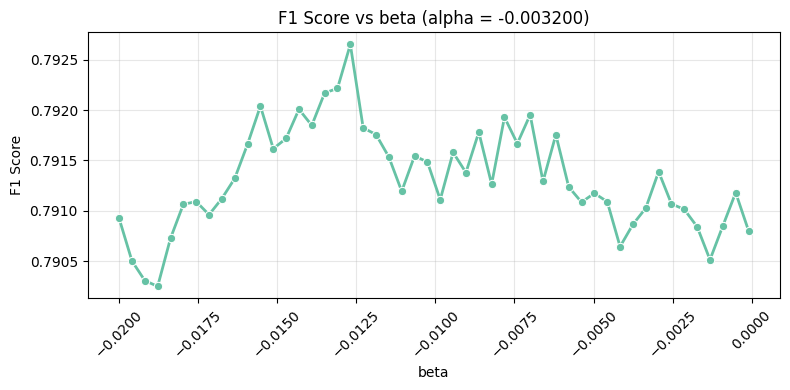

In [88]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read data
df = pd.read_csv("params.csv")

# Create subplots
fig, ax1 = plt.subplots(1, 1, figsize=(8, 4))

# F1 Score vs Beta
sns.lineplot(data=df, x='beta', y='f1_score', ax=ax1, marker='o', linewidth=2, markersize=6)
ax1.set_title(f'F1 Score vs beta (alpha = -{df["alpha"].iloc[0]:.6f})')
ax1.set_xlabel('beta')
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel('F1 Score')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()